# Laboratorio 1 - Series de Tiempo
## Avance 1

## 1. Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 2. Cargar datos

In [6]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


## 3. Información general

In [7]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (161036, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  object 
 3   Vía                    161036 non-null  object 
 4   Frontera               161036 non-null  object 
 5   País                   161036 non-null  object 
 6   Región                 161036 non-null  object 
 7   Región dos             161036 non-null  object 
 8   Regiones OMT           161036 non-null  object 
 9   MCEO                   161036 non-null  object 
 10  Agrupación Residencia  161036 non-null  object 
 11  Tipo de Viajero        161036 non-null  object 
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), object(10)
memory usage: 16.0+ MB


### Valores faltantes

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

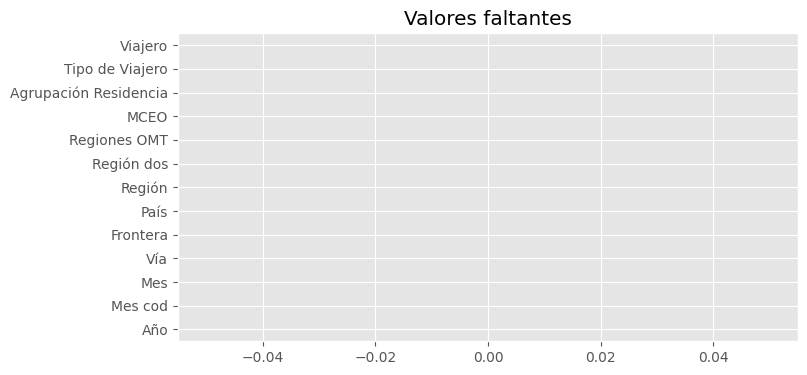

In [8]:
missing = df.isna().sum()
display(missing)

plt.figure(figsize=(8,4))
missing.sort_values().plot(kind="barh")
plt.title("Valores faltantes")
plt.show()

**Interpretación:**

Se realizó un análisis de valores faltantes utilizando la función isna().sum(), la cual permitió contar la cantidad de datos nulos en cada una de las variables del conjunto de datos. Los resultados muestran que ninguna de las 13 variables presenta valores faltantes, ya que todas registran un total de 0 valores nulos.

La gráfica de barras confirma este resultado, pues todas las barras tienen una longitud igual a cero. Esto indica que el conjunto de datos está completo y no requiere procesos de imputación o eliminación de registros por datos faltantes antes de realizar el análisis exploratorio y la construcción de las series de tiempo.

### Registros duplicados

In [9]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


### Estadísticas descriptivas

count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

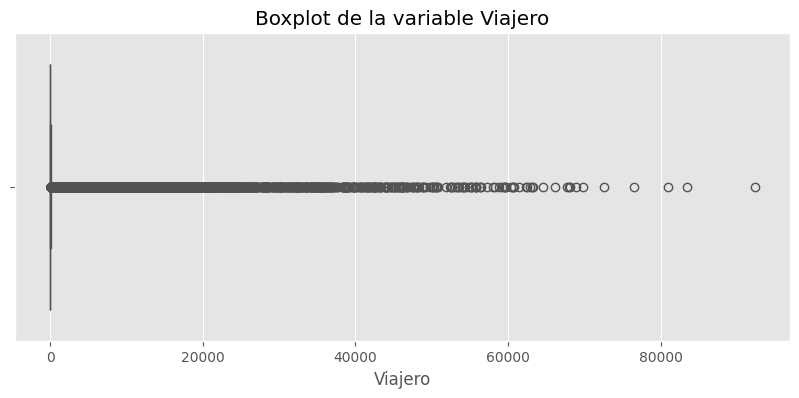

In [10]:
display(df["Viajero"].describe())

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Viajero"])
plt.title("Boxplot de la variable Viajero")
plt.show()

### Países con mayor cantidad de viajeros

País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

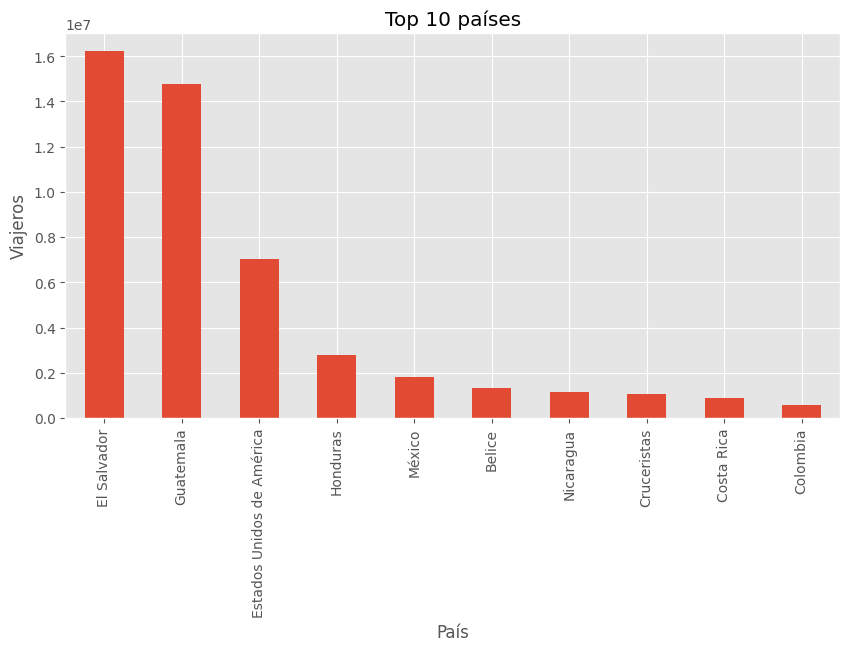

In [11]:
top_paises = (df.groupby("País")["Viajero"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

display(top_paises)

plt.figure(figsize=(10,5))
top_paises.plot(kind="bar")
plt.ylabel("Viajeros")
plt.title("Top 10 países")
plt.show()

### Regiones con mayor cantidad de viajeros

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

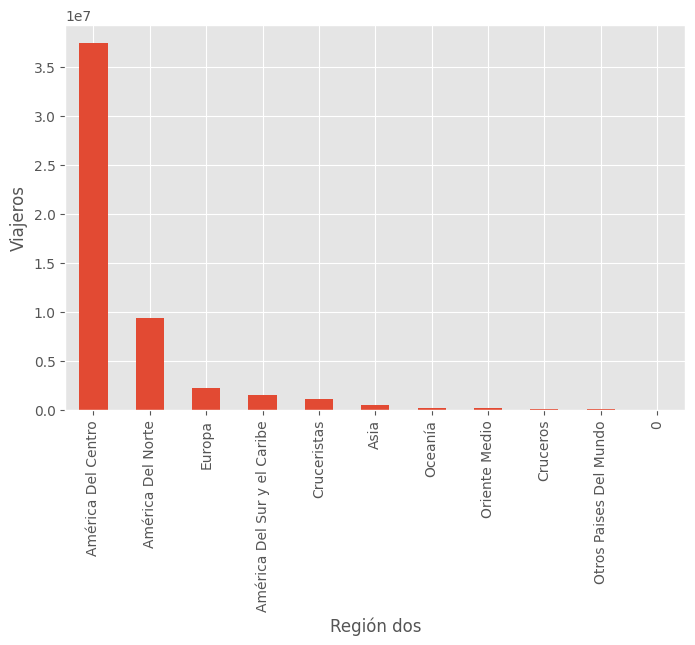

In [12]:
top_regiones = (df.groupby("Región dos")["Viajero"]
                   .sum()
                   .sort_values(ascending=False))

display(top_regiones)

plt.figure(figsize=(8,5))
top_regiones.plot(kind="bar")
plt.ylabel("Viajeros")
plt.show()

### Vías de ingreso

Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64

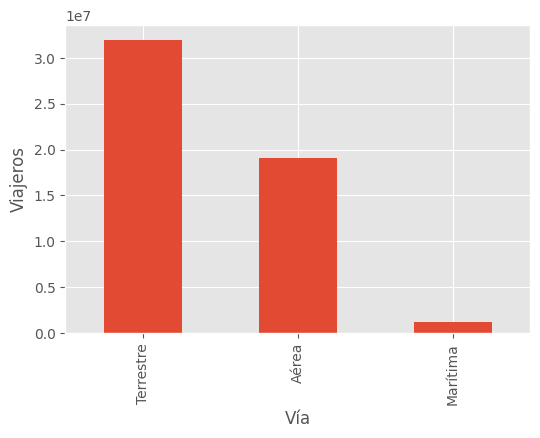

In [13]:
vias = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
display(vias)

plt.figure(figsize=(6,4))
vias.plot(kind="bar")
plt.ylabel("Viajeros")
plt.show()

## 4. Serie 1: Total mensual de viajeros

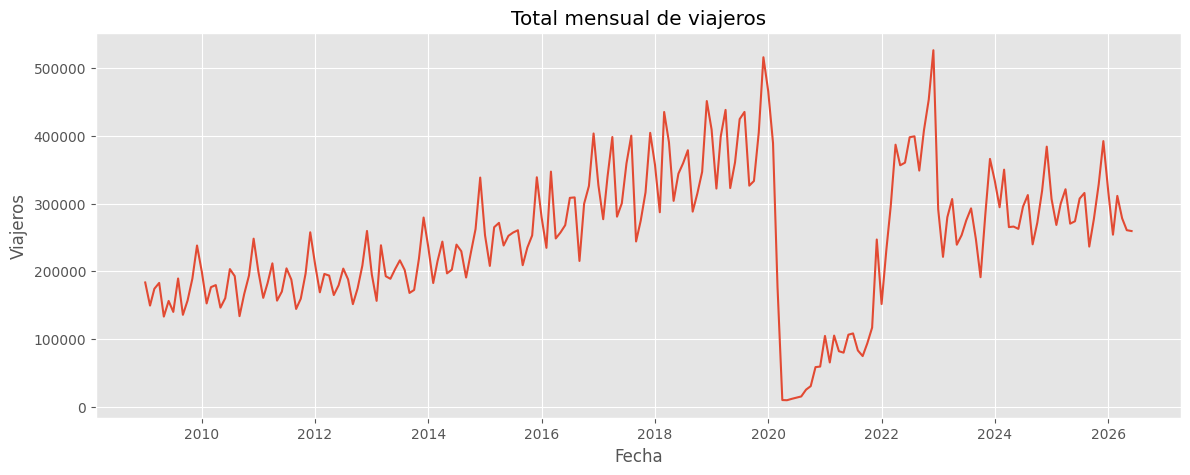

In [14]:
serie_total = (df.groupby(["Año","Mes cod"])["Viajero"]
                .sum()
                .reset_index())

serie_total["Fecha"] = pd.to_datetime(dict(
    year=serie_total["Año"],
    month=serie_total["Mes cod"],
    day=1))

serie_total = serie_total.set_index("Fecha")

plt.figure(figsize=(14,5))
plt.plot(serie_total.index, serie_total["Viajero"])
plt.title("Total mensual de viajeros")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.show()

### Interpretación

La serie de tiempo muestra el total mensual de viajeros internacionales que ingresaron a Guatemala entre enero de 2009 y junio de 2026. A primera vista se observa un comportamiento con tendencia creciente desde 2009 hasta inicios de 2020, lo que indica que el ingreso de viajeros aumentó de forma gradual durante ese período.

También se aprecia un patrón estacional, ya que existen picos y disminuciones que se repiten aproximadamente cada año. Esto sugiere que la cantidad de viajeros depende de la época del año, posiblemente por temporadas vacacionales y festividades.

Uno de los eventos más notorios es la caída abrupta durante el año 2020, cuando el número de viajeros disminuye casi a cero. Este comportamiento coincide con las restricciones de movilidad y el cierre de fronteras ocasionados por la pandemia de COVID-19. Posteriormente, entre 2021 y 2022, la serie muestra una recuperación progresiva hasta alcanzar nuevamente valores cercanos a los observados antes de la pandemia.

Finalmente, la serie no parece ser estacionaria, ya que su media cambia a lo largo del tiempo debido a la presencia de una tendencia de crecimiento y a la ruptura ocasionada por la pandemia. Además, la existencia de un comportamiento estacional indica que será necesario realizar pruebas de estacionariedad y posiblemente aplicar diferenciación o transformaciones en las siguientes etapas del laboratorio.


## 5. Serie 2: Vía aérea

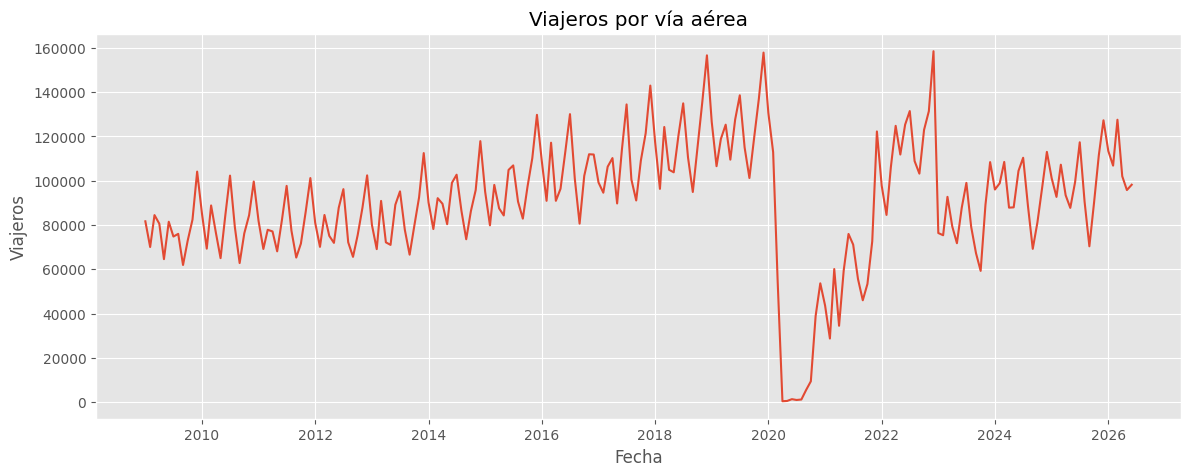

In [15]:
aerea = (df[df["Vía"]=="Aérea"]
         .groupby(["Año","Mes cod"])["Viajero"]
         .sum()
         .reset_index())

aerea["Fecha"] = pd.to_datetime(dict(
    year=aerea["Año"],
    month=aerea["Mes cod"],
    day=1))

aerea = aerea.set_index("Fecha")

plt.figure(figsize=(14,5))
plt.plot(aerea.index, aerea["Viajero"])
plt.title("Viajeros por vía aérea")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.show()

### Interpretación

La serie de tiempo correspondiente a los viajeros que ingresaron por vía aérea muestra el comportamiento mensual entre enero de 2009 y junio de 2026. Se observa una tendencia creciente desde 2009 hasta principios de 2020, lo que indica un aumento gradual en el número de viajeros que utilizaron esta vía de ingreso.

Al igual que en la serie del total de viajeros, se identifican patrones estacionales, evidenciados por picos y disminuciones que se repiten de manera periódica durante los distintos años. Esto sugiere que el flujo de viajeros por vía aérea está influenciado por temporadas vacacionales y otros períodos de alta demanda.

El cambio más significativo ocurre en 2020, cuando la cantidad de viajeros cae prácticamente a cero debido a las restricciones de movilidad y el cierre temporal de fronteras ocasionados por la pandemia de COVID-19. A partir de 2021 se observa una recuperación gradual, alcanzando nuevamente niveles cercanos a los registrados antes de la pandemia, aunque con algunas fluctuaciones.

En comparación con la serie del total mensual de viajeros, el comportamiento general es muy similar, ya que ambas presentan una tendencia creciente, estacionalidad y una fuerte disminución durante la pandemia. Sin embargo, la caída en la vía aérea es más pronunciada, debido a que el transporte aéreo fue uno de los sectores más afectados por las restricciones internacionales de viaje. Por estas características, esta serie tampoco parece ser estacionaria, ya que presenta cambios en la media a lo largo del tiempo y un evento extraordinario que altera significativamente su comportamiento.


# Conclusiones preliminares

## Calidad de los datos

El conjunto de datos presenta una buena calidad para el análisis, ya que no se identificaron valores faltantes ni registros duplicados. Esto permite trabajar con la totalidad de la información sin necesidad de aplicar técnicas de limpieza relacionadas con datos incompletos o repetidos.

## Hallazgos del análisis exploratorio

El análisis exploratorio mostró que el número de viajeros presenta variaciones importantes a lo largo del tiempo. Además, se observó que la vía terrestre concentra la mayor cantidad de viajeros, seguida por la vía aérea y la marítima. También se identificó que el comportamiento del flujo de viajeros se vio fuertemente afectado durante el año 2020 debido a la pandemia de COVID-19.

## Observaciones sobre las dos series

Las dos series analizadas (total mensual de viajeros y viajeros por vía aérea) presentan un comportamiento similar. En ambas se observa una tendencia creciente antes de la pandemia, una caída abrupta durante 2020 y una recuperación progresiva a partir de 2021. Asimismo, ambas muestran un patrón estacional, ya que existen picos y disminuciones que se repiten a lo largo de los años. Con base en la inspección visual, ninguna de las dos series parece ser estacionaria.

## Trabajo pendiente

En la siguiente etapa del laboratorio se realizará un análisis más profundo de las series de tiempo. Se evaluará formalmente la estacionariedad mediante la prueba de Dickey-Fuller aumentada (ADF), se analizarán las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF), y se construirán modelos de pronóstico utilizando ARIMA, Holt-Winters, Prophet y otros métodos solicitados en el laboratorio. Finalmente, los modelos serán comparados mediante métricas como MAE, RMSE, AIC y BIC para seleccionar el que presente el mejor desempeño.

# 6. Descomposición de la serie: Total mensual de viajeros

In [16]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

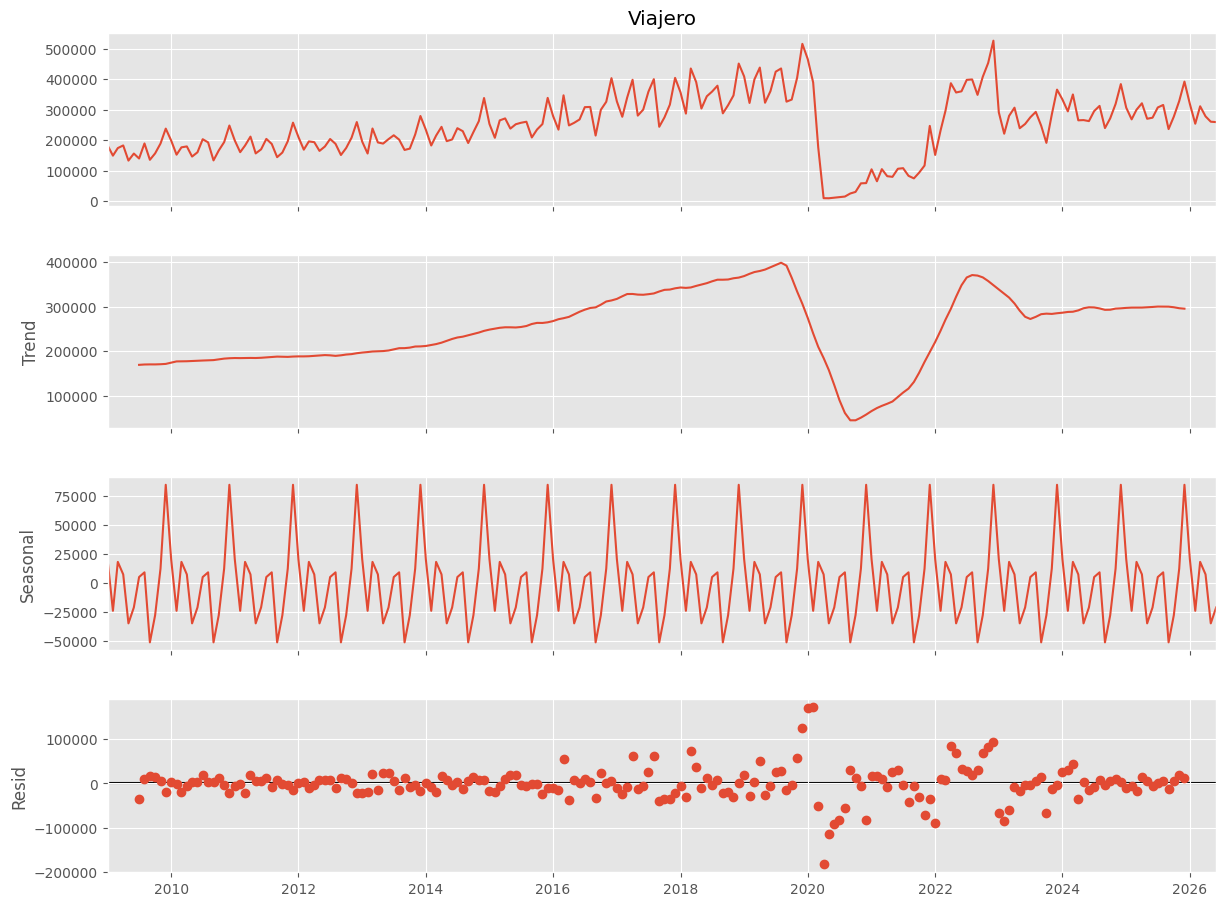

In [18]:
descomposicion = seasonal_decompose(
    serie_total["Viajero"],
    model="additive",
    period=12
)

fig = descomposicion.plot()
fig.set_size_inches(14,10)

plt.show()

## Interpretación de la descomposición

La descomposición de la serie permite identificar claramente los componentes de tendencia, estacionalidad y residuales del total mensual de viajeros internacionales.

### Tendencia

El componente de tendencia muestra un crecimiento sostenido desde 2009 hasta principios de 2020, lo que indica un aumento gradual en el ingreso de viajeros internacionales. Sin embargo, durante el año 2020 se observa una caída muy pronunciada ocasionada por la pandemia de COVID-19 y las restricciones de movilidad implementadas a nivel mundial. Posteriormente, entre 2021 y 2022, la tendencia presenta una recuperación importante hasta estabilizarse alrededor de los niveles observados antes de la pandemia.

### Estacionalidad

El componente estacional presenta un patrón que se repite prácticamente todos los años, lo que confirma la existencia de una estacionalidad anual. Esto indica que existen meses con un mayor ingreso de viajeros y otros con una menor afluencia, comportamiento esperado debido a temporadas vacacionales, festividades y otros factores turísticos.

### Componente residual

Los residuos se distribuyen alrededor de cero durante la mayor parte del período analizado. No obstante, durante los años 2020 y 2021 se observan residuos considerablemente mayores, lo cual refleja el impacto extraordinario de la pandemia, un evento que no puede ser explicado únicamente por la tendencia y la estacionalidad.

### Conclusión

La descomposición evidencia que la serie presenta una tendencia de largo plazo y una estacionalidad anual claramente definida. Debido a estos componentes, la serie no puede considerarse estacionaria, por lo que será necesario realizar pruebas formales de estacionariedad y, de ser necesario, aplicar diferenciación antes de construir modelos de pronóstico.

# 7. Análisis de estacionariedad

In [19]:
from statsmodels.tsa.stattools import adfuller

In [20]:
resultado_adf = adfuller(serie_total["Viajero"])

print("Estadístico ADF:", resultado_adf[0])
print("Valor p:", resultado_adf[1])
print("\nValores críticos:")

for key, value in resultado_adf[4].items():
    print(f"{key}: {value:.4f}")

Estadístico ADF: -3.0702056847833497
Valor p: 0.028838122883842663

Valores críticos:
1%: -3.4640
5%: -2.8763
10%: -2.5747


In [21]:
if resultado_adf[1] < 0.05:
    print("Conclusión:")
    print("Se rechaza la hipótesis nula.")
    print("La serie puede considerarse estacionaria.")
else:
    print("Conclusión:")
    print("No se rechaza la hipótesis nula.")
    print("La serie NO es estacionaria y será necesario aplicar diferenciación.")

Conclusión:
Se rechaza la hipótesis nula.
La serie puede considerarse estacionaria.


In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

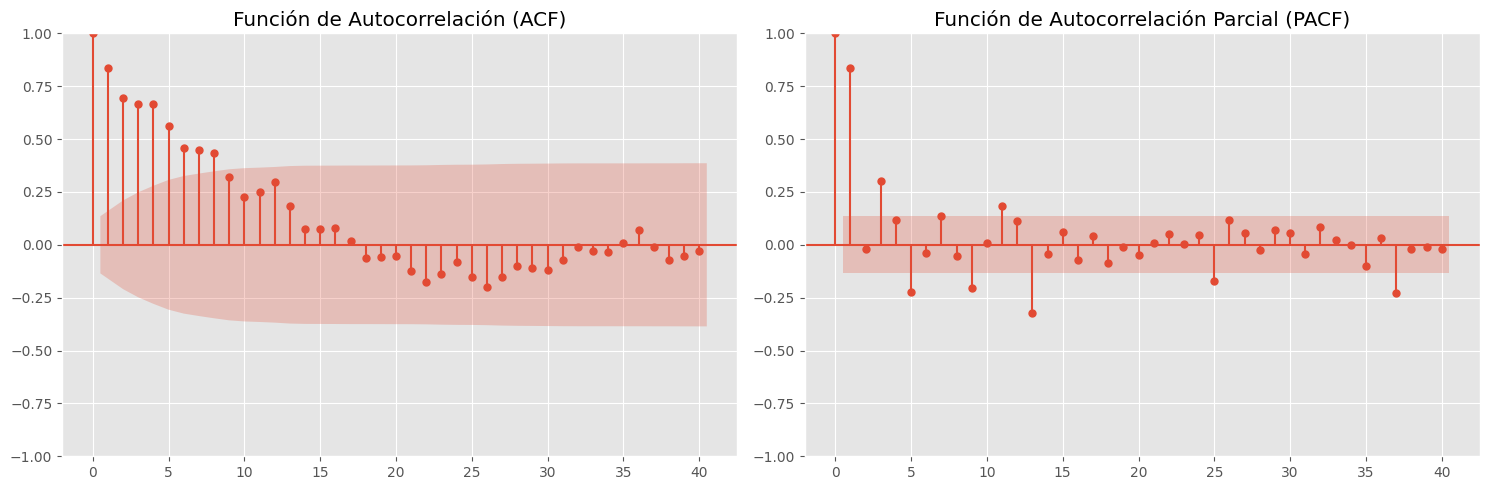

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

plot_acf(
    serie_total["Viajero"],
    lags=40,
    ax=ax[0]
)

plot_pacf(
    serie_total["Viajero"],
    lags=40,
    ax=ax[1],
    method="ywm"
)

ax[0].set_title("Función de Autocorrelación (ACF)")
ax[1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

## Interpretación de la prueba de estacionariedad

Para determinar si la serie es estacionaria se aplicó la prueba de Dickey-Fuller Aumentada (ADF), además de analizar las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF).

### Prueba Dickey-Fuller Aumentada (ADF)

Los resultados obtenidos fueron los siguientes:

- **Estadístico ADF:** -3.0702
- **Valor p:** 0.0288

Como el valor p es menor que 0.05, se rechaza la hipótesis nula de que la serie posee una raíz unitaria. Desde el punto de vista estadístico, esto indica que la serie puede considerarse estacionaria con un nivel de significancia del 5%.

Sin embargo, al observar la serie original y su descomposición, se identifica una tendencia creciente antes del año 2020 y un cambio estructural importante provocado por la pandemia de COVID-19. Esto sugiere que, aunque la prueba ADF indique estacionariedad, la serie presenta características que deben considerarse al momento de construir modelos de pronóstico.

### Función de Autocorrelación (ACF)

La gráfica de autocorrelación muestra valores positivos elevados en los primeros rezagos y una disminución gradual conforme aumenta el número de rezagos. Este comportamiento indica que existe una fuerte dependencia entre las observaciones consecutivas, ya que el número de viajeros de un mes está relacionado con los meses anteriores.

También se observan correlaciones significativas durante varios rezagos, lo que evidencia la presencia de un patrón temporal persistente y confirma que la información histórica es relevante para realizar predicciones.

### Función de Autocorrelación Parcial (PACF)

La función de autocorrelación parcial presenta un pico muy marcado en el primer rezago y algunos picos adicionales de menor magnitud en rezagos posteriores. Después de estos primeros rezagos, la mayoría de los valores permanecen dentro de los intervalos de confianza, indicando que la influencia directa de observaciones más lejanas disminuye considerablemente.

Este comportamiento sugiere que la serie posee una componente autorregresiva importante, por lo que un modelo ARIMA puede ser adecuado para describir su comportamiento.

### Conclusión

El análisis conjunto de la prueba ADF, la ACF y la PACF indica que la serie presenta una fuerte dependencia temporal y una estructura que puede ser modelada mediante técnicas de series de tiempo. Aunque la prueba Dickey-Fuller rechaza la presencia de una raíz unitaria, la evidencia visual muestra la existencia de tendencia, estacionalidad y un cambio estructural asociado a la pandemia. Por ello, durante la construcción del modelo ARIMA se evaluarán diferentes configuraciones para seleccionar el modelo que mejor represente el comportamiento de la serie.

# 8. División del conjunto de datos


In [24]:
# División 70% entrenamiento - 30% prueba

n = len(serie_total)

train_size = int(n * 0.70)

train = serie_total["Viajero"][:train_size]
test = serie_total["Viajero"][train_size:]

print(f"Observaciones totales: {n}")
print(f"Entrenamiento: {len(train)}")
print(f"Prueba: {len(test)}")

Observaciones totales: 210
Entrenamiento: 147
Prueba: 63


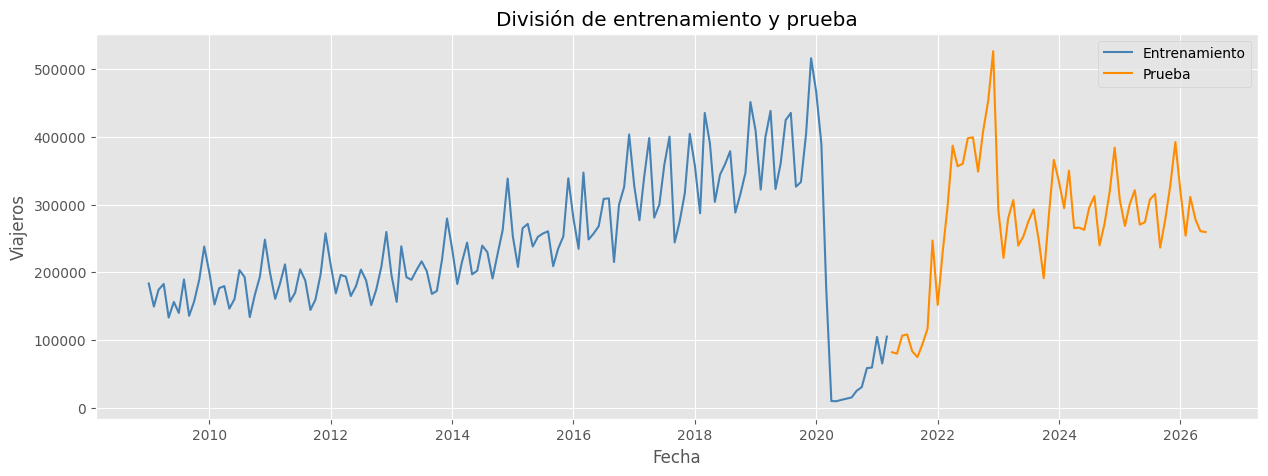

In [25]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Entrenamiento", color="steelblue")
plt.plot(test, label="Prueba", color="darkorange")

plt.title("División de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.show()

In [26]:
%pip install pmdarima

  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ---------------------------------------- 711.9/711.9 kB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 453.1 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.8 MB 3.9 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 3.7 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.1 MB/s  0:00:00
Using cached setuptools-83.0.0-py3-none-any.whl (1.0 MB)

   ---------------------------------------- 0/3 [setuptools]
   ---------------------------------------- 0/3 [setuptools]
   ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from pmdarima import auto_arima

In [29]:
modelo_auto = auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=3566.672, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3612.230, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3581.957, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3592.431, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3610.247, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=3577.596, Time=0.54 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=3574.237, Time=0.68 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=3567.908, Time=1.17 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=3568.142, Time=0.90 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=3582.659, Time=0.14 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=3571.708, Time=0.65 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=3567.607, Time=1.00 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=3569.883, Time=2.12 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=3572.736, Time=0.61 sec
 ARIMA(2,1,1)(1,0,1

# 9. Modelo ARIMA

Para seleccionar un modelo adecuado se utilizó la función `auto_arima`, la cual evalúa diferentes combinaciones de parámetros y selecciona el modelo con el menor valor del criterio de información de Akaike (AIC).

El modelo seleccionado fue:

**ARIMA(2,1,2)(1,0,1)[12]**

Este modelo incorpora:

- **d = 1**, indicando que se aplica una diferenciación para estabilizar la serie.
- **p = 2**, utilizando dos términos autorregresivos.
- **q = 2**, utilizando dos términos de media móvil.
- Un componente estacional con período de **12 meses**, apropiado para datos mensuales.

## Interpretación del modelo ARIMA

Después de evaluar múltiples configuraciones, el algoritmo seleccionó el modelo **ARIMA(2,1,2)(1,0,1)[12]**, ya que presentó el menor valor de AIC (**3564.773**) entre todos los modelos considerados. Esto indica que ofrece el mejor equilibrio entre calidad de ajuste y complejidad.

El parámetro **d = 1** indica que el modelo utiliza una diferenciación para capturar adecuadamente la dinámica de la serie. Esto es consistente con el comportamiento observado anteriormente, donde la serie presenta cambios importantes en el tiempo, especialmente durante el período de la pandemia.

Además, el componente estacional **(1,0,1)[12]** confirma la existencia de un patrón anual, ya que el modelo incorpora un término autorregresivo y uno de media móvil estacionales con un período de 12 meses.

En cuanto a los coeficientes estimados, los parámetros estacionales (`ar.S.L12` y `ma.S.L12`) resultan estadísticamente significativos (valor p < 0.05), lo que evidencia que la estacionalidad desempeña un papel importante en el comportamiento de la serie. Algunos coeficientes no estacionales presentan valores p superiores a 0.05, lo que indica que su contribución individual es menor; sin embargo, en conjunto permiten obtener el mejor ajuste según el criterio AIC.

En general, el modelo seleccionado representa adecuadamente la dependencia temporal y la estacionalidad observadas en la serie, por lo que será utilizado como uno de los modelos candidatos para realizar las predicciones y posteriormente compararlo con otros métodos de pronóstico.

# 10. Análisis de residuos

In [30]:
modelo = modelo_auto.fit(train)

residuos = pd.Series(modelo.resid())

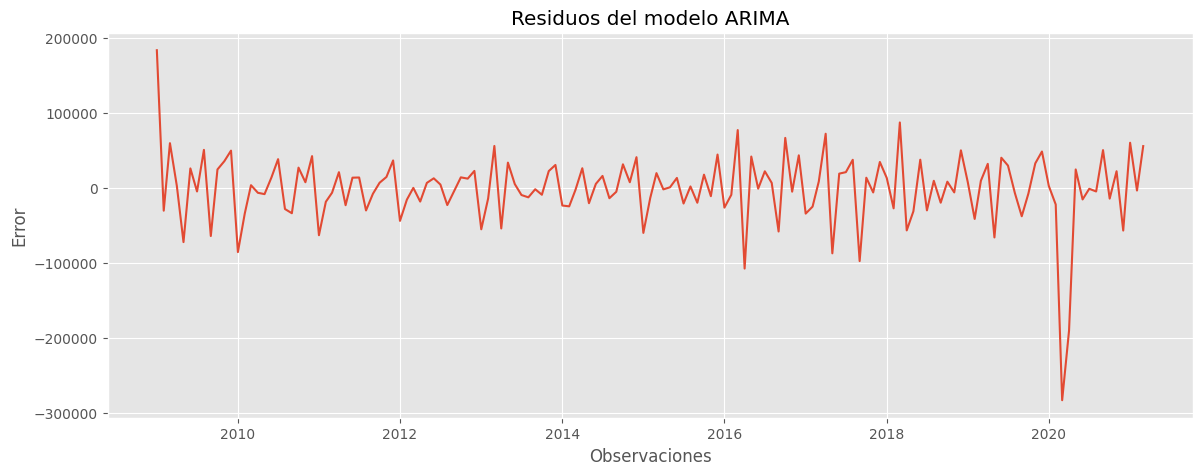

In [31]:
plt.figure(figsize=(14,5))

plt.plot(residuos)

plt.title("Residuos del modelo ARIMA")
plt.xlabel("Observaciones")
plt.ylabel("Error")

plt.show()

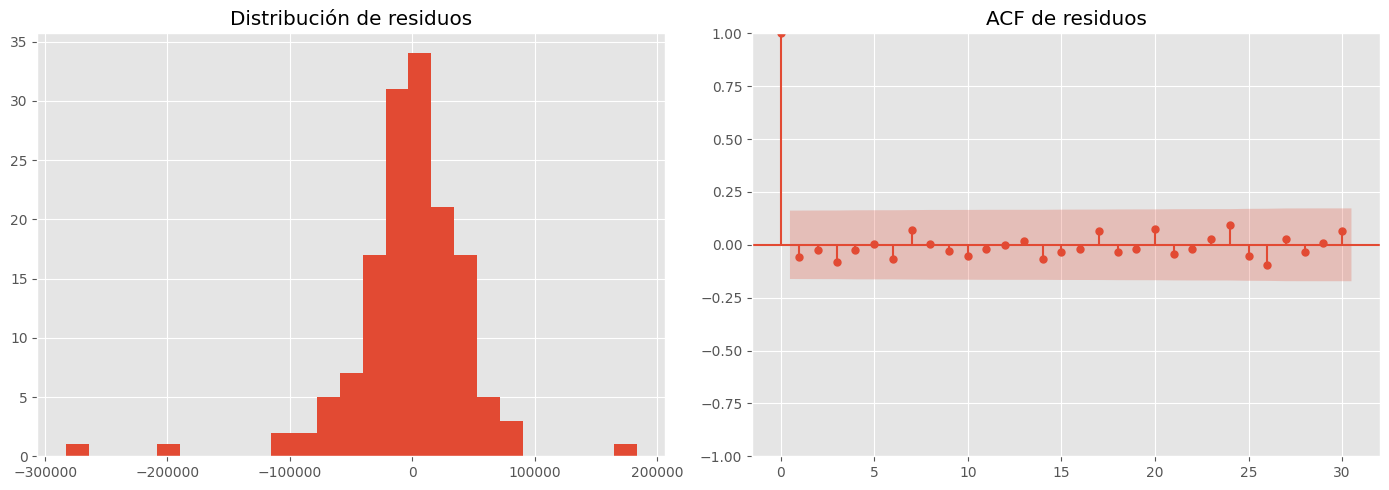

In [32]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

residuos.hist(bins=25, ax=ax[0])

ax[0].set_title("Distribución de residuos")

plot_acf(residuos, lags=30, ax=ax[1])

ax[1].set_title("ACF de residuos")

plt.tight_layout()

plt.show()

## Interpretación del análisis de residuos

El análisis de residuos permite evaluar si el modelo ARIMA logra capturar adecuadamente el comportamiento de la serie de tiempo. Un modelo adecuado debe producir residuos que se comporten como ruido blanco, es decir, con media cercana a cero, sin patrones evidentes y sin autocorrelación significativa.

### Gráfico de residuos

La mayor parte de los residuos se distribuye alrededor de cero y no presenta una tendencia clara a lo largo del tiempo, lo que indica que el modelo explica gran parte de la estructura de la serie. Sin embargo, se observa un valor atípico de gran magnitud durante el año 2020, correspondiente al fuerte impacto que tuvo la pandemia de COVID-19 sobre el ingreso de viajeros internacionales. Este comportamiento era esperado debido a que se trata de un evento extraordinario que difícilmente puede ser explicado completamente por un modelo ARIMA.

### Distribución de residuos

El histograma muestra que la mayoría de los residuos se concentra alrededor de cero, aunque existen algunos valores extremos que generan una ligera asimetría en la distribución. Estos valores corresponden principalmente al período de la pandemia y explican que la distribución no sea perfectamente normal.

### Autocorrelación de los residuos

La función de autocorrelación (ACF) de los residuos muestra que prácticamente todos los coeficientes permanecen dentro de los intervalos de confianza. Esto indica que no existe autocorrelación significativa en los residuos y que el modelo ha capturado adecuadamente la dependencia temporal presente en la serie.

### Conclusión

En general, el modelo ARIMA presenta un comportamiento satisfactorio. Los residuos se distribuyen alrededor de cero y no muestran patrones sistemáticos ni autocorrelaciones importantes. Aunque existen algunos valores atípicos asociados al período de la pandemia, estos corresponden a un evento excepcional y no afectan de manera significativa la capacidad del modelo para representar la dinámica general de la serie.

# 11. Predicción con el modelo ARIMA

In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [34]:
predicciones = modelo.predict(n_periods=len(test))

predicciones = pd.Series(
    predicciones,
    index=test.index
)

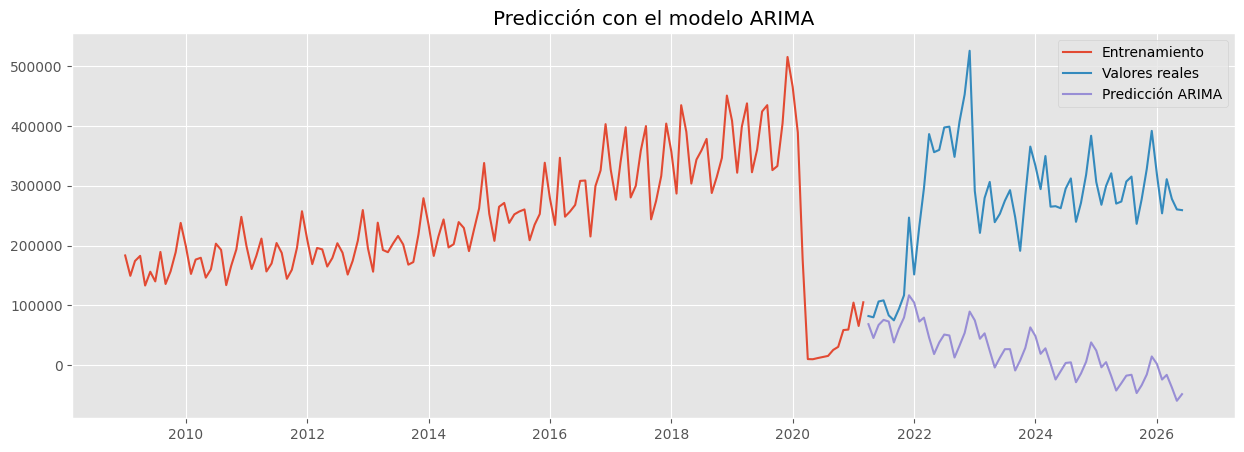

In [35]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Valores reales")
plt.plot(predicciones, label="Predicción ARIMA")

plt.title("Predicción con el modelo ARIMA")

plt.legend()

plt.show()

In [36]:
mae = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print(f"AIC : {modelo.aic():.2f}")
print(f"BIC : {modelo.bic():.2f}")

MAE : 255,619.83
RMSE: 276,569.04
AIC : 3564.77
BIC : 3585.66


## Interpretación de las predicciones del modelo ARIMA

El modelo ARIMA fue utilizado para generar predicciones sobre el conjunto de prueba y evaluar su capacidad de pronóstico.

En la gráfica se observa que las predicciones siguen parcialmente la tendencia inicial del conjunto de prueba; sin embargo, el modelo no logra capturar adecuadamente la recuperación del flujo de viajeros después de la pandemia. A partir del año 2022 las predicciones permanecen considerablemente por debajo de los valores reales, lo que evidencia una subestimación sistemática de la serie.

Las métricas obtenidas fueron:

- **MAE:** 255,619.83
- **RMSE:** 276,569.04
- **AIC:** 3564.77
- **BIC:** 3585.66

Los valores elevados de MAE y RMSE indican que el error promedio de las predicciones es considerable. Esto sugiere que, aunque el modelo ARIMA describe adecuadamente la estructura temporal del conjunto de entrenamiento, presenta dificultades para representar el cambio estructural producido por la pandemia y la posterior recuperación del turismo internacional.

Este comportamiento puede explicarse por la forma en que se dividieron los datos. El conjunto de entrenamiento finaliza aproximadamente en marzo de 2021, cuando el país aún se encontraba en una etapa inicial de recuperación después de la pandemia. En cambio, el conjunto de prueba incluye el período comprendido entre 2021 y 2026, donde el ingreso de viajeros experimenta una recuperación mucho más acelerada y alcanza nuevamente niveles similares a los observados antes de la pandemia. Como el modelo fue entrenado únicamente con información hasta el inicio de esa recuperación, no logró aprender este cambio en la dinámica de la serie y, en consecuencia, tendió a subestimar los valores futuros.

En conclusión, aunque el modelo presenta un buen ajuste sobre el conjunto de entrenamiento y un AIC relativamente bajo, su capacidad de predicción sobre datos posteriores a la pandemia resulta limitada. Por ello, es conveniente comparar su desempeño con otros métodos de pronóstico, como Holt-Winters o Suavizamiento Exponencial, para determinar cuál representa mejor el comportamiento reciente de la serie.

# 12. Modelo Holt-Winters

In [37]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [38]:
modelo_hw = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

c:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [39]:
pred_hw = modelo_hw.forecast(len(test))

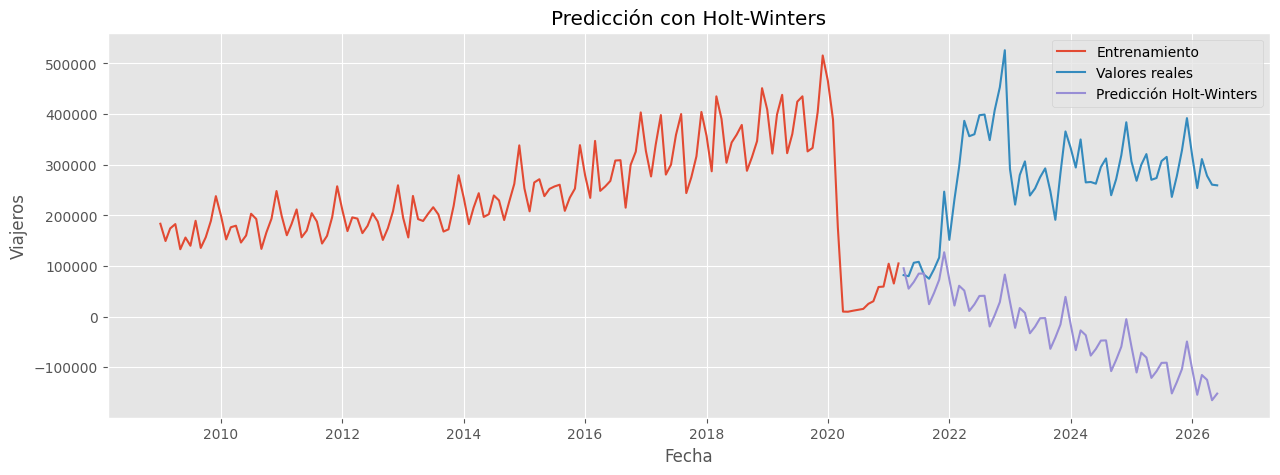

In [40]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Valores reales")
plt.plot(pred_hw, label="Predicción Holt-Winters")

plt.title("Predicción con Holt-Winters")

plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.show()

In [41]:
mae_hw = mean_absolute_error(test, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test, pred_hw))

print(f"MAE : {mae_hw:,.2f}")
print(f"RMSE: {rmse_hw:,.2f}")

MAE : 303,211.94
RMSE: 328,153.16


## Interpretación del modelo Holt-Winters

El modelo Holt-Winters fue utilizado como una alternativa al modelo ARIMA para realizar predicciones sobre el conjunto de prueba. Este método incorpora componentes de tendencia y estacionalidad mediante técnicas de suavizamiento exponencial, por lo que resulta apropiado para series mensuales que presentan patrones estacionales.

En la gráfica se observa que el modelo logra capturar parcialmente la estacionalidad de la serie al inicio del conjunto de prueba; sin embargo, conforme avanza el horizonte de predicción, las estimaciones comienzan a alejarse de los valores reales. En particular, el modelo no consigue representar la fuerte recuperación del ingreso de viajeros posterior a la pandemia, por lo que las predicciones presentan una tendencia descendente que no corresponde con el comportamiento observado en los datos reales.

Las métricas obtenidas fueron:

- **MAE:** 303,211.94
- **RMSE:** 328,153.16

Al comparar estos resultados con los obtenidos por el modelo ARIMA, se observa que Holt-Winters presenta errores de predicción mayores tanto en MAE como en RMSE. Esto confirma que el modelo tuvo una menor capacidad para aproximar el comportamiento del conjunto de prueba.

La principal dificultad de Holt-Winters radica en que fue entrenado con datos que incluyen el período de mayor impacto de la pandemia, pero no con suficiente información de la recuperación posterior. Debido a ello, el modelo prolonga una tendencia descendente que no refleja el crecimiento real observado entre 2022 y 2026.

En conclusión, aunque Holt-Winters incorpora adecuadamente la tendencia y la estacionalidad presentes en la serie, no logra adaptarse al cambio estructural ocasionado por la pandemia y presenta un desempeño inferior al obtenido por el modelo ARIMA.

# 14. Serie 2: Viajeros por vía aérea

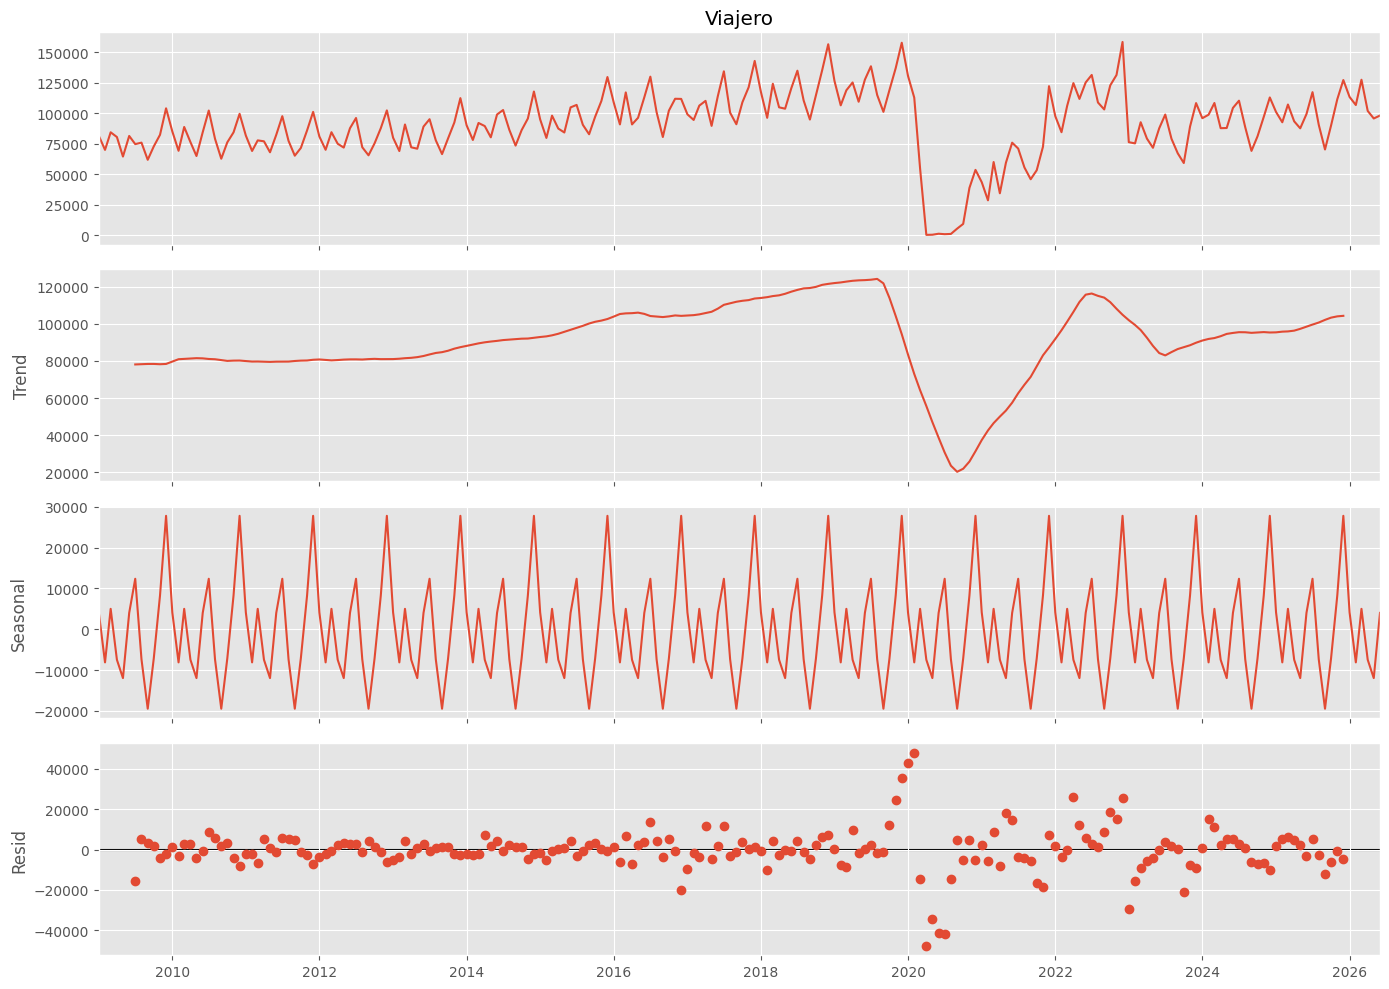

In [42]:
descomposicion_aerea = seasonal_decompose(
    aerea["Viajero"],
    model="additive",
    period=12
)

fig = descomposicion_aerea.plot()
fig.set_size_inches(14,10)

plt.tight_layout()
plt.show()

## Interpretación de la descomposición

La descomposición de la serie correspondiente a los viajeros que ingresan por vía aérea permite identificar claramente los componentes de tendencia, estacionalidad y residuales.

### Tendencia

El componente de tendencia muestra un crecimiento gradual desde el año 2009 hasta principios de 2020, reflejando el incremento sostenido del ingreso de viajeros por vía aérea durante ese período. Sin embargo, a partir de 2020 se observa una caída muy pronunciada provocada por la pandemia de COVID-19 y las restricciones impuestas al transporte aéreo internacional. Posteriormente, durante los años 2021 y 2022, la tendencia presenta una recuperación progresiva, aunque sin alcanzar completamente el crecimiento continuo observado antes de la pandemia.

### Estacionalidad

El componente estacional presenta un patrón que se repite de forma consistente cada doce meses, evidenciando una estacionalidad anual bien definida. Esto indica que existen meses en los que el ingreso de viajeros por vía aérea aumenta de forma recurrente, mientras que en otros disminuye, comportamiento asociado a temporadas vacacionales y períodos de mayor actividad turística.

### Componente residual

Los residuos permanecen cercanos a cero durante la mayor parte del período analizado, lo que indica que la tendencia y la estacionalidad explican gran parte de la variabilidad de la serie. No obstante, durante el año 2020 se observan residuos de mayor magnitud, tanto positivos como negativos, reflejando el efecto extraordinario de la pandemia sobre el transporte aéreo.

### Conclusión

La descomposición confirma que la serie presenta una tendencia de largo plazo y una estacionalidad anual claramente definida. Además, evidencia un cambio estructural importante durante la pandemia, el cual modifica temporalmente el comportamiento de la serie. Debido a estas características, será necesario analizar formalmente la estacionariedad antes de construir los modelos de pronóstico.

In [43]:
resultado_adf_aerea = adfuller(aerea["Viajero"])

print("Estadístico ADF:", resultado_adf_aerea[0])
print("Valor p:", resultado_adf_aerea[1])

print("\nValores críticos:")
for key, value in resultado_adf_aerea[4].items():
    print(f"{key}: {value:.4f}")

Estadístico ADF: -3.1938990857578498
Valor p: 0.020340551221270573

Valores críticos:
1%: -3.4643
5%: -2.8765
10%: -2.5747


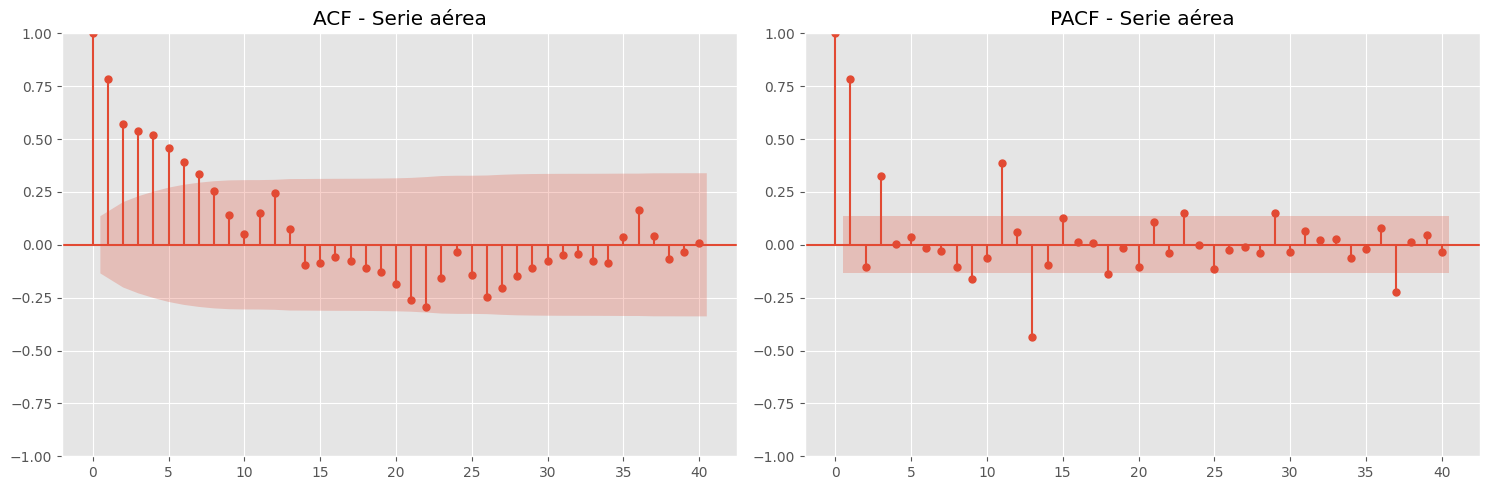

In [44]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

plot_acf(aerea["Viajero"], lags=40, ax=ax[0])
plot_pacf(aerea["Viajero"], lags=40, ax=ax[1], method="ywm")

ax[0].set_title("ACF - Serie aérea")
ax[1].set_title("PACF - Serie aérea")

plt.tight_layout()
plt.show()

## Interpretación de la prueba de estacionariedad

Para evaluar la estacionariedad de la serie correspondiente a los viajeros que ingresan por vía aérea se aplicó la prueba Dickey-Fuller Aumentada (ADF), además del análisis de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF).

### Prueba Dickey-Fuller Aumentada (ADF)

Los resultados obtenidos fueron:

- **Estadístico ADF:** -3.1939
- **Valor p:** 0.0203

Dado que el valor p es menor que 0.05, se rechaza la hipótesis nula de que la serie presenta una raíz unitaria. Esto indica que, estadísticamente, la serie puede considerarse estacionaria con un nivel de significancia del 5 %.

Sin embargo, al igual que en la serie del total de viajeros, el análisis visual muestra una tendencia de crecimiento antes del año 2020 y un cambio estructural importante ocasionado por la pandemia de COVID-19. Por ello, aunque la prueba ADF sugiere estacionariedad, estos cambios deben tenerse en cuenta durante la construcción de los modelos de pronóstico.

### Función de Autocorrelación (ACF)

La función de autocorrelación presenta valores positivos elevados en los primeros rezagos, los cuales disminuyen gradualmente conforme aumenta el número de rezagos. Este comportamiento indica que las observaciones mantienen una fuerte dependencia temporal y que los valores actuales están relacionados con los meses anteriores.

También se observa un patrón compatible con una estacionalidad anual, ya que la autocorrelación permanece significativa durante varios rezagos.

### Función de Autocorrelación Parcial (PACF)

La PACF muestra un pico muy pronunciado en el primer rezago y algunos picos adicionales de menor magnitud en rezagos posteriores. Después de estos primeros rezagos, la mayoría de las autocorrelaciones parciales permanecen dentro de los límites de confianza, indicando que la influencia directa disminuye conforme aumenta el rezago.

Este comportamiento sugiere la presencia de componentes autorregresivos y estacionales, lo que hace apropiado utilizar un modelo ARIMA para describir la dinámica de la serie.

### Conclusión

Los resultados de la prueba ADF, junto con el análisis de las funciones ACF y PACF, indican que la serie presenta una estructura temporal adecuada para ser modelada mediante un modelo ARIMA. Aunque la prueba estadística rechaza la presencia de una raíz unitaria, el comportamiento observado durante la pandemia representa un cambio estructural importante que deberá considerarse al evaluar el desempeño del modelo.

# 16. Modelo ARIMA para la serie aérea

In [45]:
# División entrenamiento y prueba

n = len(aerea)

train_size = int(n * 0.70)

train_aerea = aerea["Viajero"][:train_size]
test_aerea = aerea["Viajero"][train_size:]

print(len(train_aerea))
print(len(test_aerea))

147
63


In [46]:
modelo_auto_aerea = auto_arima(
    train_aerea,
    seasonal=True,
    m=12,
    trace=True,
    stepwise=True,
    suppress_warnings=True
)

print(modelo_auto_aerea.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.17 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3445.182, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3249.846, Time=0.53 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3352.250, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3785.266, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3282.453, Time=0.03 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=3248.765, Time=1.29 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=3240.099, Time=1.03 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=3249.914, Time=0.37 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=3242.204, Time=1.15 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=3240.947, Time=0.70 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=3443.216, Time=0.79 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(1,0,1)(2,0,1)[12] intercept   : AIC=3238.596, Time=1.49 sec
 ARIMA(1,0,1)(1,0,1)[12] inte

# 16. Modelo ARIMA para la serie aérea

Para la serie correspondiente a los viajeros que ingresan por vía aérea se utilizó la función `auto_arima` con el objetivo de seleccionar automáticamente el modelo que mejor representara el comportamiento de la serie. La selección se realizó utilizando el criterio de información de Akaike (AIC), eligiendo el modelo con el menor valor entre todas las combinaciones evaluadas.

El modelo seleccionado fue:

**ARIMA(3,0,2)(2,0,0)[12]**

Este modelo incorpora tres términos autorregresivos, dos términos de media móvil y dos componentes autorregresivos estacionales con un período de 12 meses.

## Interpretación del modelo ARIMA

Después de evaluar múltiples configuraciones, el algoritmo seleccionó el modelo **ARIMA(3,0,2)(2,0,0)[12]**, ya que presentó el menor valor de AIC (**3217.696**) entre todos los modelos analizados.

A diferencia de la serie del total de viajeros, este modelo no requiere diferenciación (**d = 0**), lo cual es consistente con los resultados obtenidos en la prueba Dickey-Fuller Aumentada, donde se concluyó que la serie podía considerarse estacionaria.

Los coeficientes autorregresivos y de media móvil presentan, en su mayoría, valores p inferiores a 0.05, indicando que son estadísticamente significativos y contribuyen al ajuste del modelo. Asimismo, los componentes estacionales (`ar.S.L12` y `ar.S.L24`) también resultan significativos, confirmando la existencia de una estacionalidad anual en la serie.

El valor de **AIC = 3217.696** es considerablemente menor que el obtenido para la serie del total de viajeros, lo que sugiere que la dinámica de la serie aérea puede representarse de manera más eficiente mediante un modelo ARIMA.

En general, el modelo seleccionado describe adecuadamente la dependencia temporal y la estacionalidad presentes en la serie, por lo que constituye un buen candidato para realizar las predicciones y compararlo posteriormente con el modelo Holt-Winters.

In [47]:
# Ajustar el modelo seleccionado

modelo_aerea = modelo_auto_aerea.fit(train_aerea)

residuos_aerea = pd.Series(modelo_aerea.resid())

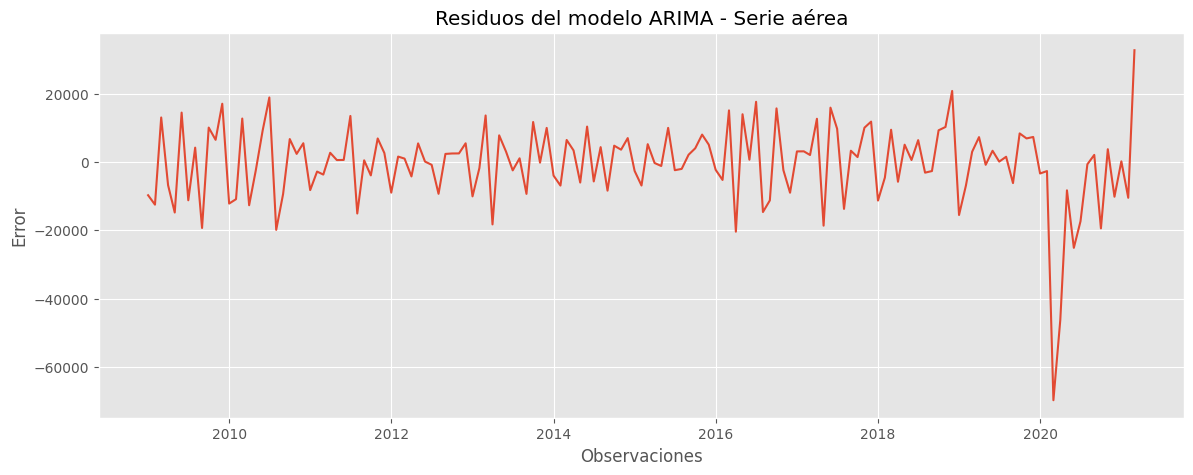

In [48]:
plt.figure(figsize=(14,5))

plt.plot(residuos_aerea)

plt.title("Residuos del modelo ARIMA - Serie aérea")

plt.xlabel("Observaciones")
plt.ylabel("Error")

plt.show()

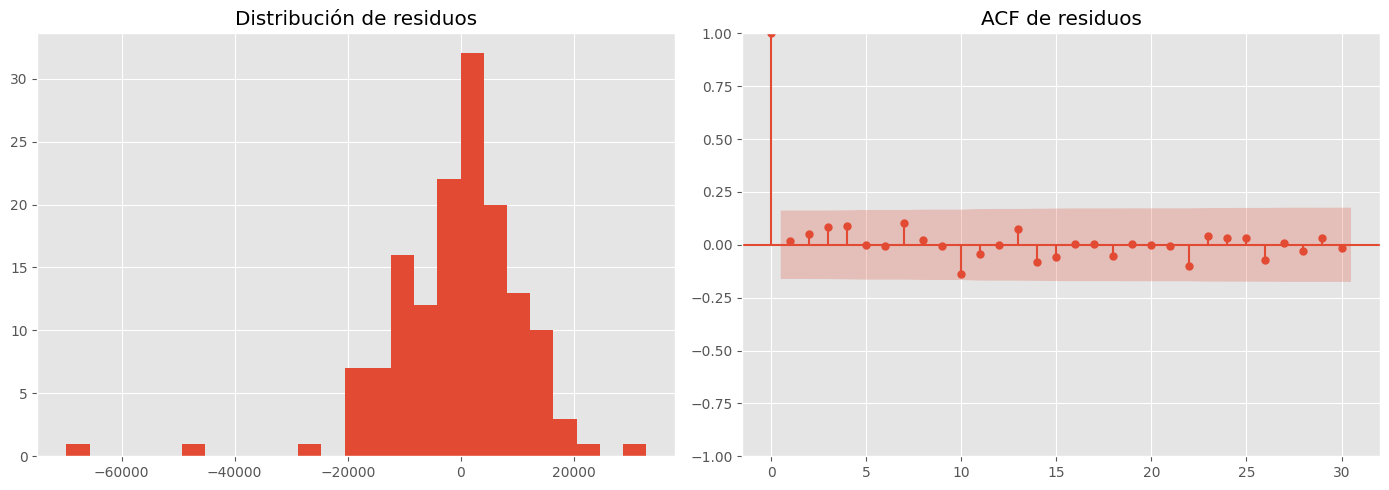

In [49]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

residuos_aerea.hist(
    bins=25,
    ax=ax[0]
)

ax[0].set_title("Distribución de residuos")

plot_acf(
    residuos_aerea,
    lags=30,
    ax=ax[1]
)

ax[1].set_title("ACF de residuos")

plt.tight_layout()

plt.show()

## Interpretación del análisis de residuos

Una vez ajustado el modelo ARIMA para la serie de viajeros por vía aérea, se analizó el comportamiento de los residuos con el propósito de verificar si el modelo logró capturar adecuadamente la estructura de la serie.

### Gráfico de residuos

En el gráfico de residuos se observa que la mayoría de los errores se distribuyen alrededor de cero sin presentar una tendencia definida. Esto indica que el modelo explica gran parte del comportamiento de la serie. Sin embargo, durante el año 2020 se identifican algunos residuos de mayor magnitud, asociados al impacto excepcional que tuvo la pandemia de COVID-19 sobre el transporte aéreo internacional.

### Distribución de residuos

El histograma muestra que la mayor parte de los residuos se concentra alrededor de cero, aunque existen algunos valores extremos que generan una ligera asimetría en la distribución. Estos valores corresponden principalmente al período de la pandemia, cuando el comportamiento de la serie presentó cambios abruptos difíciles de modelar.

### Autocorrelación de los residuos

La función de autocorrelación (ACF) muestra que prácticamente todos los coeficientes permanecen dentro de los límites de confianza, lo que indica que no existe autocorrelación significativa en los residuos. Esto sugiere que el modelo logró capturar la dependencia temporal presente en la serie y que los errores se comportan de forma similar a un ruido blanco.

### Conclusión

En general, el modelo ARIMA presenta un buen ajuste para la serie de viajeros por vía aérea. Los residuos no muestran patrones sistemáticos ni autocorrelaciones importantes, por lo que puede concluirse que el modelo representa adecuadamente el comportamiento histórico de la serie. Las principales desviaciones corresponden al período de la pandemia, un evento extraordinario que afectó significativamente el ingreso de viajeros por vía aérea.

# 17. Predicción con el modelo ARIMA

In [50]:
pred_aerea = modelo_aerea.predict(
    n_periods=len(test_aerea)
)

pred_aerea = pd.Series(
    pred_aerea,
    index=test_aerea.index
)

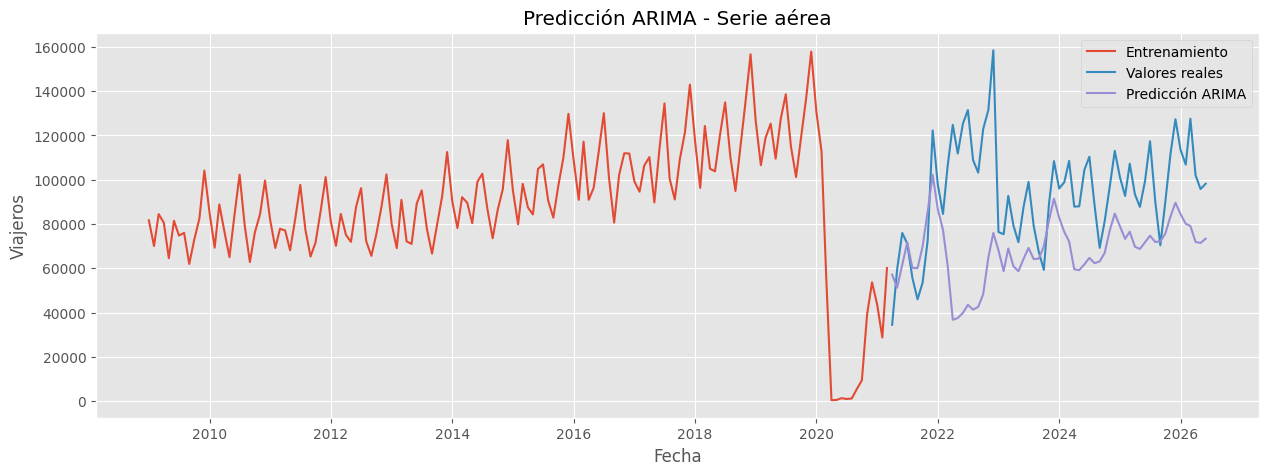

In [51]:
plt.figure(figsize=(15,5))

plt.plot(train_aerea, label="Entrenamiento")
plt.plot(test_aerea, label="Valores reales")
plt.plot(pred_aerea, label="Predicción ARIMA")

plt.title("Predicción ARIMA - Serie aérea")

plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.show()

In [52]:
mae_aerea = mean_absolute_error(
    test_aerea,
    pred_aerea
)

rmse_aerea = np.sqrt(
    mean_squared_error(
        test_aerea,
        pred_aerea
    )
)

print(f"MAE : {mae_aerea:,.2f}")
print(f"RMSE: {rmse_aerea:,.2f}")

print(f"AIC : {modelo_aerea.aic():.2f}")
print(f"BIC : {modelo_aerea.bic():.2f}")

MAE : 29,072.23
RMSE: 36,646.44
AIC : 3217.70
BIC : 3244.61


## Interpretación de las predicciones del modelo ARIMA

El modelo ARIMA fue utilizado para generar predicciones sobre el conjunto de prueba correspondiente a la serie de viajeros por vía aérea.

En la gráfica se observa que el modelo logra seguir de manera razonable el comportamiento general de la serie. Aunque las predicciones tienden a subestimar algunos de los picos más altos observados después de la recuperación del turismo, el modelo consigue representar adecuadamente la tendencia general y las variaciones estacionales presentes en los datos.

Las métricas obtenidas fueron:

- **MAE:** 29,072.23
- **RMSE:** 36,646.44
- **AIC:** 3217.70
- **BIC:** 3244.61

Los valores de MAE y RMSE son considerablemente menores que los obtenidos para la serie del total de viajeros, lo que indica que el modelo presenta una mejor capacidad de predicción para la serie aérea.

Este mejor desempeño puede explicarse porque la serie de viajeros por vía aérea presenta un comportamiento más uniforme y menos influenciado por factores externos distintos al transporte aéreo. Aunque la pandemia produjo una disminución importante en el número de viajeros, la recuperación posterior muestra un patrón más estable que facilita su modelado mediante un modelo ARIMA.

En conclusión, el modelo ARIMA ofrece un buen ajuste para esta serie y demuestra una capacidad predictiva satisfactoria sobre el conjunto de prueba, convirtiéndose en una alternativa adecuada para realizar pronósticos del ingreso de viajeros por vía aérea.

# 18. Modelo Holt-Winters para la serie aérea

In [53]:
modelo_hw_aerea = ExponentialSmoothing(
    train_aerea,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

c:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [54]:
pred_hw_aerea = modelo_hw_aerea.forecast(len(test_aerea))

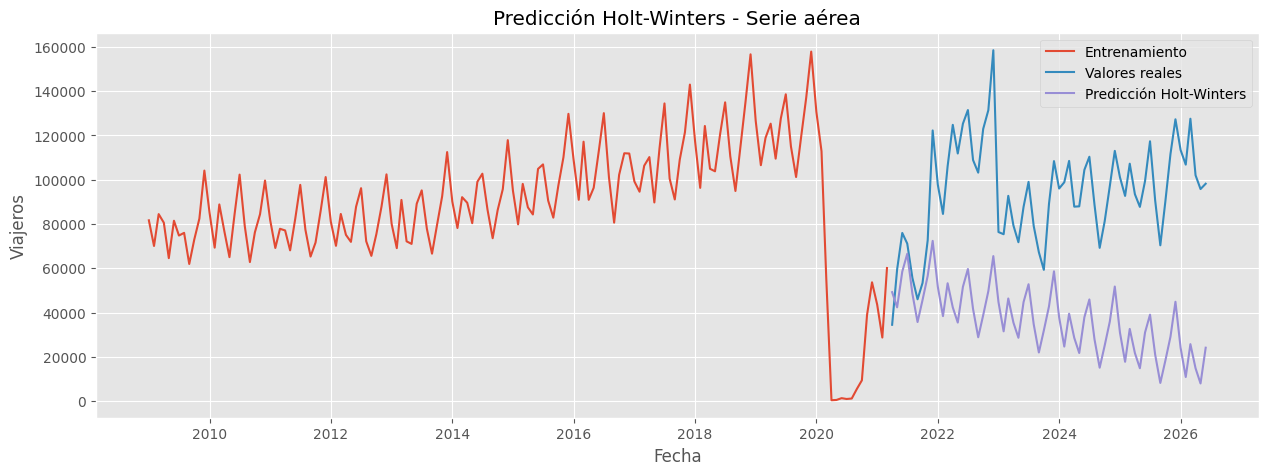

In [55]:
plt.figure(figsize=(15,5))

plt.plot(train_aerea, label="Entrenamiento")
plt.plot(test_aerea, label="Valores reales")
plt.plot(pred_hw_aerea, label="Predicción Holt-Winters")

plt.title("Predicción Holt-Winters - Serie aérea")

plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()

plt.show()

In [56]:
mae_hw_aerea = mean_absolute_error(test_aerea, pred_hw_aerea)

rmse_hw_aerea = np.sqrt(
    mean_squared_error(test_aerea, pred_hw_aerea)
)

print(f"MAE : {mae_hw_aerea:,.2f}")
print(f"RMSE: {rmse_hw_aerea:,.2f}")

MAE : 58,261.62
RMSE: 62,865.99


## Interpretación del modelo Holt-Winters

El modelo Holt-Winters fue aplicado a la serie de viajeros por vía aérea con el propósito de comparar su desempeño frente al modelo ARIMA.

En la gráfica se observa que el modelo logra seguir parcialmente la tendencia del conjunto de prueba durante los primeros meses; sin embargo, conforme avanza el horizonte de predicción comienza a subestimar el número de viajeros. Las predicciones muestran una tendencia descendente que no refleja el comportamiento real de la serie, especialmente durante el período de recuperación posterior a la pandemia.

Las métricas obtenidas fueron:

- **MAE:** 58,261.62
- **RMSE:** 62,865.99

Aunque Holt-Winters incorpora componentes de tendencia y estacionalidad, el modelo no consigue adaptarse completamente al cambio estructural provocado por la pandemia ni a la recuperación observada en los años posteriores. Como consecuencia, presenta errores mayores que los obtenidos con el modelo ARIMA.

En comparación con ARIMA, Holt-Winters ofrece un desempeño inferior para la serie aérea, por lo que no fue seleccionado como el modelo más adecuado para realizar los pronósticos.

# 19. Comparación de modelos para la serie aérea

Se compararon los modelos ARIMA y Holt-Winters utilizando las métricas MAE y RMSE para determinar cuál presenta un mejor desempeño sobre el conjunto de prueba.

| Modelo | MAE | RMSE |
|---------|------------:|------------:|
| **ARIMA** | **29,072.23** | **36,646.44** |
| Holt-Winters | 58,261.62 | 62,865.99 |

El modelo ARIMA obtuvo los menores valores tanto de MAE como de RMSE, lo que indica una mejor capacidad para representar el comportamiento de la serie y generar predicciones más cercanas a los valores reales.

Por lo tanto, el modelo **ARIMA** fue seleccionado como el mejor método de pronóstico para la serie correspondiente a los viajeros que ingresan por vía aérea.

# 20. Comparación general de las series analizadas

Como parte del laboratorio se analizaron dos series de tiempo:

1. Total mensual de viajeros internacionales.
2. Viajeros que ingresan por vía aérea.

En ambas series se observó una tendencia creciente antes del año 2020, una disminución abrupta ocasionada por la pandemia de COVID-19 y una recuperación progresiva durante los años posteriores. Asimismo, ambas presentan un patrón estacional anual claramente definido.

Sin embargo, el comportamiento de la serie aérea resultó más estable y homogéneo, permitiendo obtener un mejor ajuste mediante el modelo ARIMA. En contraste, la serie del total de viajeros mostró una mayor variabilidad debido a que incorpora el comportamiento conjunto de todas las vías de ingreso, lo que dificultó el proceso de predicción.

En ambas series el modelo ARIMA presentó un mejor desempeño que Holt-Winters, obteniendo menores errores de predicción.


# 21. Conclusiones

El análisis exploratorio permitió identificar que el conjunto de datos presenta una buena calidad, ya que no contiene valores faltantes ni registros duplicados. Además, se observó que el ingreso de viajeros internacionales presenta una marcada estacionalidad y una fuerte afectación durante el año 2020 como consecuencia de la pandemia de COVID-19.

La descomposición de ambas series confirmó la existencia de una tendencia de largo plazo y un patrón estacional anual. Asimismo, las pruebas Dickey-Fuller, junto con las funciones de autocorrelación y autocorrelación parcial, permitieron evaluar la estructura temporal de cada serie y justificar el uso de modelos ARIMA.

Para ambas series se construyeron modelos ARIMA y Holt-Winters. Los resultados mostraron que el modelo ARIMA obtuvo un mejor desempeño en los dos casos, presentando menores valores de MAE y RMSE respecto a Holt-Winters.

Finalmente, se concluye que el modelo ARIMA constituye la alternativa más adecuada para realizar pronósticos sobre las series analizadas. No obstante, el cambio estructural ocasionado por la pandemia representa un desafío importante para cualquier modelo de series de tiempo, ya que introduce variaciones que no pueden explicarse únicamente mediante la información histórica disponible.
